# 📏 Métriques d'Évaluation des Modèles d'IA

Bienvenue dans ce notebook sur les **métriques d'évaluation** !

Un modèle d'IA n'est utile que si on sait **mesurer ses performances**. Les métriques permettent de répondre à la question : *Mon modèle est-il bon ? Et par rapport à quoi ?*

## Table des matières
1. [Métriques de Classification](#1)
2. [La Matrice de Confusion](#2)
3. [Courbe ROC et AUC](#3)
4. [Métriques de Régression](#4)
5. [Validation Croisée](#5)
6. [Comparaison de Modèles](#6)
7. [Choisir la Bonne Métrique](#7)

---
> 💡 **Objectif** : Comprendre et utiliser les métriques pour évaluer correctement un modèle.

## 📦 0. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Métriques de classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# Métriques de régression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## 1. Métriques de Classification <a id='1'></a>

En **classification**, le modèle prédit une **catégorie** (ex. : malade/sain, spam/non-spam).

### Préparation du dataset

Nous utilisons le dataset **Iris** avec 3 espèces à classer.

In [2]:
# Chargement du dataset Iris
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
especes = iris.target_names

# Division : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Entraînement d'un KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)

print('=== Résultats du modèle KNN ===')
print(f'Taille ensemble entraînement : {len(X_train)}')
print(f'Taille ensemble test         : {len(X_test)}')
print(f'\nPremières prédictions : {y_pred[:10]}')
print(f'Vraies valeurs        : {y_test.values[:10]}')

=== Résultats du modèle KNN ===
Taille ensemble entraînement : 120
Taille ensemble test         : 30

Premières prédictions : [0 2 1 1 0 1 0 0 2 1]
Vraies valeurs        : [0 2 1 1 0 1 0 0 2 1]


### 1.1 L'Exactitude (Accuracy)

L'**exactitude** est la métrique la plus simple :

$$\text{Accuracy} = \frac{\text{Nombre de bonnes prédictions}}{\text{Nombre total de prédictions}}$$

> ⚠️ Attention : l'accuracy peut être trompeuse sur des **données déséquilibrées** !

In [3]:
# Calcul de l'accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Exactitude (Accuracy) : {acc:.4f} = {acc*100:.1f}%')

# Explication visuelle
n_total = len(y_test)
n_correct = (y_test.values == y_pred).sum()
n_wrong = n_total - n_correct

print(f'\n  Total de prédictions  : {n_total}')
print(f'  Bonnes prédictions    : {n_correct}')
print(f'  Mauvaises prédictions : {n_wrong}')
print(f'  Accuracy = {n_correct}/{n_total} = {acc:.2f}')

Exactitude (Accuracy) : 0.9333 = 93.3%

  Total de prédictions  : 30
  Bonnes prédictions    : 28
  Mauvaises prédictions : 2
  Accuracy = 28/30 = 0.93


### 1.2 Précision, Rappel et F1-Score

Ces 3 métriques sont basées sur 4 valeurs fondamentales :

| | Prédit Positif | Prédit Négatif |
|---|---|---|
| **Réel Positif** | ✅ VP (Vrai Positif) | ❌ FN (Faux Négatif) |
| **Réel Négatif** | ❌ FP (Faux Positif) | ✅ VN (Vrai Négatif) |

$$\text{Précision} = \frac{VP}{VP + FP} \quad \text{(qualité des prédictions positives)}$$

$$\text{Rappel} = \frac{VP}{VP + FN} \quad \text{(capacité à trouver tous les positifs)}$$

$$\text{F1-Score} = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}} \quad \text{(compromis précision/rappel)}$$

In [4]:
# Calcul des métriques
print('=== Métriques par espèce ===')
print()
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'Précision : {precision_score(y_test, y_pred, average="weighted"):.3f}')
print(f'Rappel    : {recall_score(y_test, y_pred, average="weighted"):.3f}')
print(f'F1-Score  : {f1_score(y_test, y_pred, average="weighted"):.3f}')
print()
print('=== Rapport complet par classe ===')
print(classification_report(y_test, y_pred, target_names=especes))

=== Métriques par espèce ===

Accuracy  : 0.933
Précision : 0.944
Rappel    : 0.933
F1-Score  : 0.933

=== Rapport complet par classe ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



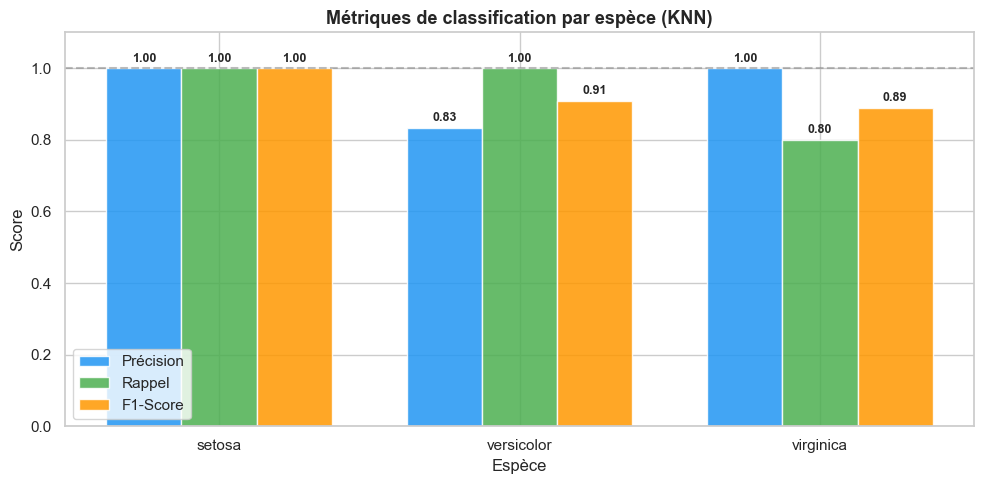

In [5]:
# Visualisation des métriques par classe
from sklearn.metrics import precision_score, recall_score, f1_score

metriques = {
    'Précision': precision_score(y_test, y_pred, average=None),
    'Rappel': recall_score(y_test, y_pred, average=None),
    'F1-Score': f1_score(y_test, y_pred, average=None),
}

x = np.arange(len(especes))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

couleurs = ['#2196F3', '#4CAF50', '#FF9800']
for i, (nom, vals) in enumerate(metriques.items()):
    bars = ax.bar(x + i*width, vals, width, label=nom, color=couleurs[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Espèce', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métriques de classification par espèce (KNN)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(especes)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 1.3 Quand utiliser quelle métrique ?

| Contexte | Métrique recommandée |
|----------|----------------------|
| Classes équilibrées | Accuracy |
| Éviter les faux positifs (spam) | Précision |
| Éviter les faux négatifs (maladie) | Rappel |
| Équilibre entre les deux | F1-Score |
| Classes déséquilibrées | F1-Score ou AUC |

## 2. La Matrice de Confusion <a id='2'></a>

La **matrice de confusion** est l'outil le plus puissant pour analyser les erreurs d'un classificateur.

Chaque ligne = **vraie classe**, chaque colonne = **classe prédite**.

In [6]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print('=== Matrice de confusion ===')
print(cm)
print()
print('Lecture : ligne = vraie classe, colonne = classe prédite')
print('Diagonal = bonnes prédictions, hors-diagonale = erreurs')

=== Matrice de confusion ===
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Lecture : ligne = vraie classe, colonne = classe prédite
Diagonal = bonnes prédictions, hors-diagonale = erreurs


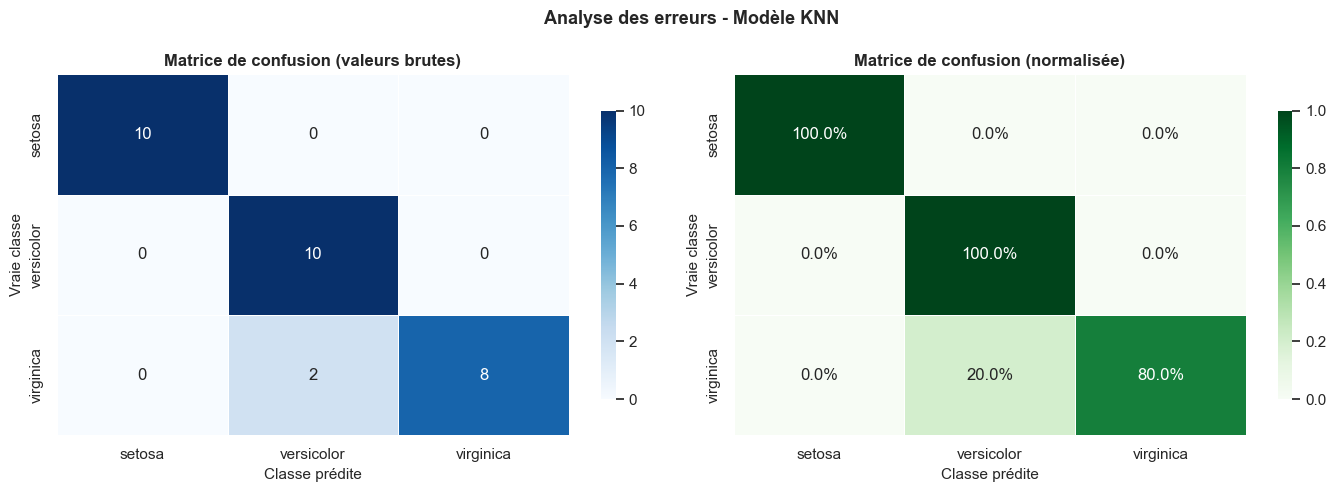

💡 La diagonale verte = bonnes prédictions.
   Les cases hors-diagonale = erreurs de classification.


In [7]:
# Visualisation de la matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Valeurs brutes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=especes, yticklabels=especes, ax=axes[0],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Matrice de confusion (valeurs brutes)', fontweight='bold')
axes[0].set_ylabel('Vraie classe', fontsize=11)
axes[0].set_xlabel('Classe prédite', fontsize=11)

# 2. Normalisée (pourcentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=especes, yticklabels=especes, ax=axes[1],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Matrice de confusion (normalisée)', fontweight='bold')
axes[1].set_ylabel('Vraie classe', fontsize=11)
axes[1].set_xlabel('Classe prédite', fontsize=11)

plt.suptitle('Analyse des erreurs - Modèle KNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 La diagonale verte = bonnes prédictions.')
print('   Les cases hors-diagonale = erreurs de classification.')

## 3. Courbe ROC et AUC <a id='3'></a>

La **courbe ROC** (*Receiver Operating Characteristic*) et l'**AUC** (*Area Under the Curve*) évaluent la capacité du modèle à distinguer les classes.

- **AUC = 1.0** : modèle parfait
- **AUC = 0.5** : modèle aléatoire (comme lancer une pièce)
- **AUC < 0.5** : modèle pire que le hasard

> 💡 La courbe ROC est particulièrement utile pour les **problèmes binaires** (2 classes).

In [8]:
# Simplification en problème binaire : setosa vs non-setosa
from sklearn.preprocessing import label_binarize

# Préparer données binaires
y_bin = (y == 0).astype(int)  # 1 = setosa, 0 = autre
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

scaler2 = StandardScaler()
X_train_b_sc = scaler2.fit_transform(X_train_b)
X_test_b_sc = scaler2.transform(X_test_b)

# Entraîner le modèle et obtenir les probabilités
knn_bin = KNeighborsClassifier(n_neighbors=5)
knn_bin.fit(X_train_b_sc, y_train_b)
y_proba = knn_bin.predict_proba(X_test_b_sc)[:, 1]  # Proba de la classe 1

# Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test_b, y_proba)
auc_score = auc(fpr, tpr)

print(f'AUC (Area Under the Curve) = {auc_score:.4f}')

AUC (Area Under the Curve) = 1.0000


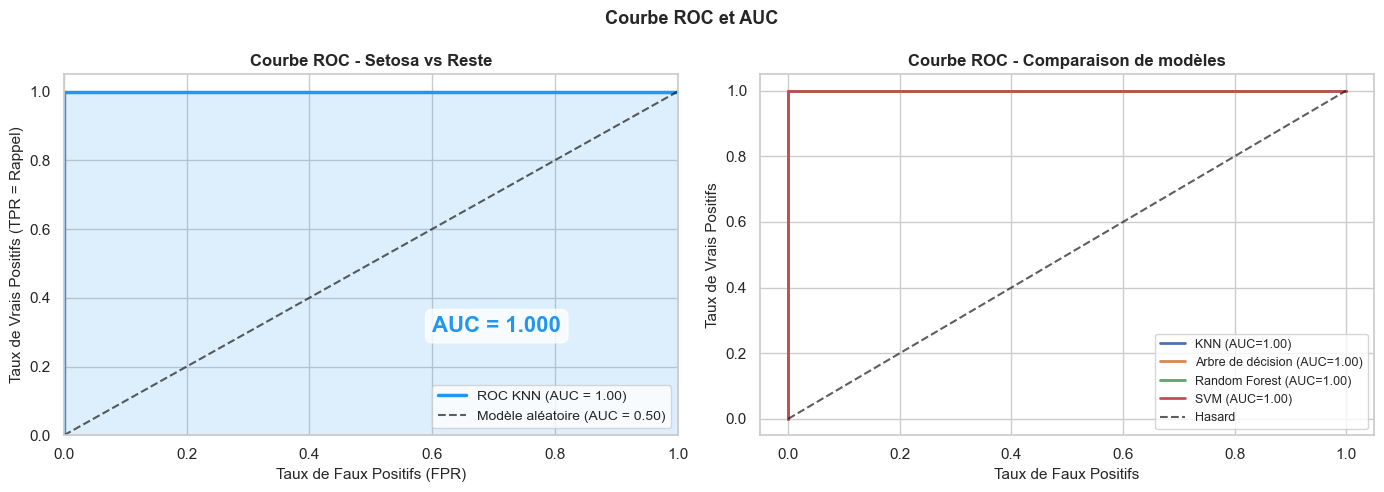

In [9]:
# Visualisation de la courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
axes[0].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC KNN (AUC = {auc_score:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Modèle aléatoire (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#2196F3')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
axes[0].set_ylabel('Taux de Vrais Positifs (TPR = Rappel)', fontsize=11)
axes[0].set_title('Courbe ROC - Setosa vs Reste', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].text(0.6, 0.3, f'AUC = {auc_score:.3f}', fontsize=16, fontweight='bold',
             color='#2196F3', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Comparaison de plusieurs modèles
modeles = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Arbre de décision': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

for nom, modele in modeles.items():
    modele.fit(X_train_b_sc, y_train_b)
    proba = modele.predict_proba(X_test_b_sc)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test_b, proba)
    auc_m = auc(fpr_m, tpr_m)
    axes[1].plot(fpr_m, tpr_m, lw=2, label=f'{nom} (AUC={auc_m:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Hasard')
axes[1].set_xlabel('Taux de Faux Positifs', fontsize=11)
axes[1].set_ylabel('Taux de Vrais Positifs', fontsize=11)
axes[1].set_title('Courbe ROC - Comparaison de modèles', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Courbe ROC et AUC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Métriques de Régression <a id='4'></a>

En **régression**, le modèle prédit une **valeur numérique continue** (ex. : prix, température).

### Les métriques principales :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Erreur moyenne en unité d'origine |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Pénalise davantage les grandes erreurs |
| **RMSE** | $\sqrt{MSE}$ | MSE en unité d'origine |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | % de variance expliquée (0 à 1) |

In [10]:
# Dataset Diabetes (régression)
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Modèle de régression linéaire
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

print('=== Métriques de régression - Régression linéaire ===')
print()
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f'MAE  (Erreur Absolue Moyenne)   : {mae:.2f}')
print(f'MSE  (Erreur Quadratique Moy.)  : {mse:.2f}')
print(f'RMSE (Racine de MSE)            : {rmse:.2f}')
print(f'R²   (Coefficient de détermination) : {r2:.4f} ({r2*100:.1f}%)')
print()
print(f'Interprétation R² = {r2:.2f} :')
print(f'  Le modèle explique {r2*100:.1f}% de la variance de la cible.')

=== Métriques de régression - Régression linéaire ===

MAE  (Erreur Absolue Moyenne)   : 42.79
MSE  (Erreur Quadratique Moy.)  : 2900.19
RMSE (Racine de MSE)            : 53.85
R²   (Coefficient de détermination) : 0.4526 (45.3%)

Interprétation R² = 0.45 :
  Le modèle explique 45.3% de la variance de la cible.


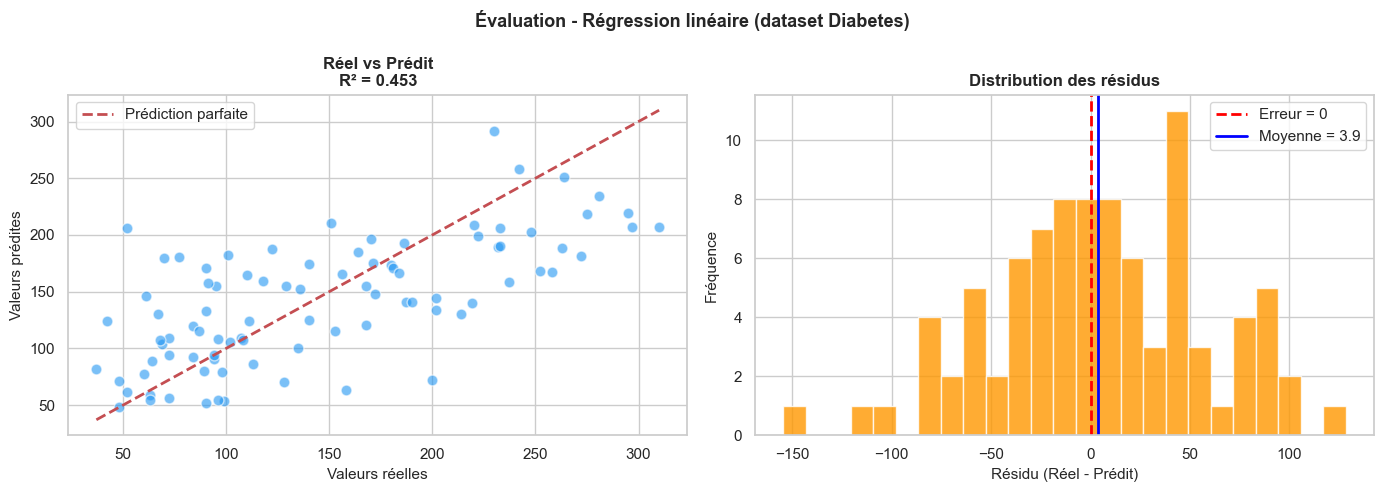

💡 Les résidus doivent être centrés en 0 et symétriques.
   Une distribution non-symétrique indique un problème systématique.


In [11]:
# Visualisation : valeurs réelles vs prédites
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter : réel vs prédit
axes[0].scatter(y_test_r, y_pred_r, alpha=0.6, color='#2196F3', edgecolors='white', s=60)
min_val, max_val = min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles', fontsize=11)
axes[0].set_ylabel('Valeurs prédites', fontsize=11)
axes[0].set_title(f'Réel vs Prédit\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
axes[0].legend()

# Distribution des résidus
residus = y_test_r - y_pred_r
axes[1].hist(residus, bins=25, color='#FF9800', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1].axvline(x=residus.mean(), color='blue', linestyle='-', linewidth=2,
                label=f'Moyenne = {residus.mean():.1f}')
axes[1].set_xlabel('Résidu (Réel - Prédit)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title('Distribution des résidus', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Évaluation - Régression linéaire (dataset Diabetes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Les résidus doivent être centrés en 0 et symétriques.')
print('   Une distribution non-symétrique indique un problème systématique.')

## 5. Validation Croisée <a id='5'></a>

Un seul découpage train/test peut donner des résultats **chanceux ou malchanceux**. La **validation croisée** (cross-validation) évalue le modèle sur **plusieurs découpages** pour obtenir une estimation plus fiable.

### Principe du K-Fold :

Diviser les données en **K groupes** (folds) → entraîner K fois en alternant le groupe de test.

In [12]:
# Illustration du K-Fold
print('=== Principe de la validation croisée K-Fold (K=5) ===')
print()
print('Données divisées en 5 folds :')
for i in range(1, 6):
    test_fold = f'[TEST]'
    folds = ['Train'] * 5
    folds[i-1] = test_fold
    print(f'  Itération {i}: {" | ".join(folds)}')
print()
print('→ Score final = moyenne des 5 scores')

=== Principe de la validation croisée K-Fold (K=5) ===

Données divisées en 5 folds :
  Itération 1: [TEST] | Train | Train | Train | Train
  Itération 2: Train | [TEST] | Train | Train | Train
  Itération 3: Train | Train | [TEST] | Train | Train
  Itération 4: Train | Train | Train | [TEST] | Train
  Itération 5: Train | Train | Train | Train | [TEST]

→ Score final = moyenne des 5 scores


In [13]:
# Validation croisée avec sklearn
print('=== Validation croisée (5-Fold) - Dataset Iris ===\n')

modeles_cv = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Arbre de décision': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(random_state=42)
}

scaler_cv = StandardScaler()
X_sc_cv = scaler_cv.fit_transform(X)

resultats_cv = {}
for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X_sc_cv, y, cv=5, scoring='accuracy')
    resultats_cv[nom] = scores
    print(f'{nom}:')
    print(f'  Scores par fold : {[f"{s:.3f}" for s in scores]}')
    print(f'  Moyenne ± Écart-type : {scores.mean():.3f} ± {scores.std():.3f}\n')

=== Validation croisée (5-Fold) - Dataset Iris ===

KNN (k=5):
  Scores par fold : ['0.967', '0.967', '0.933', '0.933', '1.000']
  Moyenne ± Écart-type : 0.960 ± 0.025

Arbre de décision:
  Scores par fold : ['0.967', '0.967', '0.900', '0.933', '1.000']
  Moyenne ± Écart-type : 0.953 ± 0.034

Random Forest:
  Scores par fold : ['0.967', '0.967', '0.933', '0.933', '1.000']
  Moyenne ± Écart-type : 0.960 ± 0.025

SVM:
  Scores par fold : ['0.967', '0.967', '0.967', '0.933', '1.000']
  Moyenne ± Écart-type : 0.967 ± 0.021



/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_10119/3570915481.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=[n.replace(' ', '\n') for n in noms],


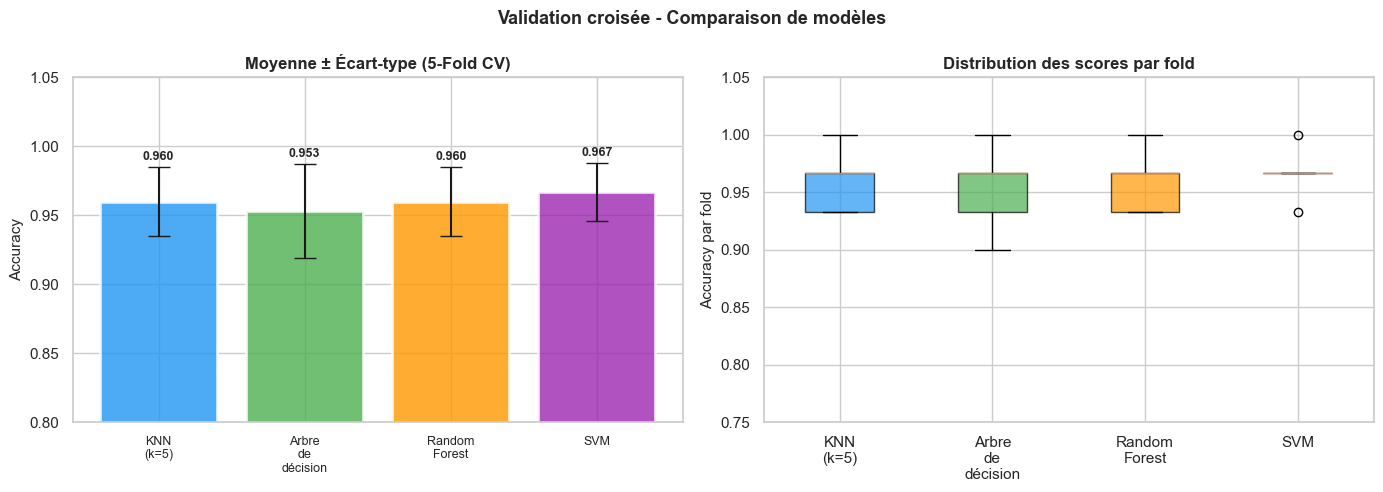

💡 Un écart-type faible = modèle stable et généralisable.


In [14]:
# Visualisation de la validation croisée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

noms = list(resultats_cv.keys())
moyennes = [resultats_cv[n].mean() for n in noms]
ecart_types = [resultats_cv[n].std() for n in noms]
couleurs_cv = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Barplot avec barres d'erreur
bars = axes[0].bar(range(len(noms)), moyennes, yerr=ecart_types,
                    color=couleurs_cv, alpha=0.8, edgecolor='white',
                    capsize=8, linewidth=2)
axes[0].set_xticks(range(len(noms)))
axes[0].set_xticklabels([n.replace(' ', '\n') for n in noms], fontsize=9)
axes[0].set_ylim(0.8, 1.05)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Moyenne ± Écart-type (5-Fold CV)', fontsize=12, fontweight='bold')
for i, (m, s) in enumerate(zip(moyennes, ecart_types)):
    axes[0].text(i, m + s + 0.005, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Boxplot des scores
data_box = [resultats_cv[n] for n in noms]
bp = axes[1].boxplot(data_box, labels=[n.replace(' ', '\n') for n in noms],
                      patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], couleurs_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Accuracy par fold', fontsize=11)
axes[1].set_title('Distribution des scores par fold', fontsize=12, fontweight='bold')
axes[1].set_ylim(0.75, 1.05)

plt.suptitle('Validation croisée - Comparaison de modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Un écart-type faible = modèle stable et généralisable.')

## 6. Comparaison de Modèles <a id='6'></a>

Comparons maintenant plusieurs modèles **sur toutes les métriques** à la fois.

In [15]:
# Comparaison complète de classification
print('=== Comparaison complète des modèles de classification ===\n')

resultats = []
for nom, modele in modeles_cv.items():
    modele.fit(X_train_sc, y_train)
    y_p = modele.predict(X_test_sc)
    resultats.append({
        'Modèle': nom,
        'Accuracy': accuracy_score(y_test, y_p),
        'Précision': precision_score(y_test, y_p, average='weighted'),
        'Rappel': recall_score(y_test, y_p, average='weighted'),
        'F1-Score': f1_score(y_test, y_p, average='weighted'),
    })

df_resultats = pd.DataFrame(resultats).set_index('Modèle')
print(df_resultats.round(4).to_string())
print(f'\nMeilleur modèle (F1-Score) : {df_resultats["F1-Score"].idxmax()}')

=== Comparaison complète des modèles de classification ===

                   Accuracy  Précision  Rappel  F1-Score
Modèle                                                  
KNN (k=5)            0.9333     0.9444  0.9333    0.9327
Arbre de décision    0.9333     0.9333  0.9333    0.9333
Random Forest        0.9000     0.9024  0.9000    0.8997
SVM                  0.9667     0.9697  0.9667    0.9666

Meilleur modèle (F1-Score) : SVM


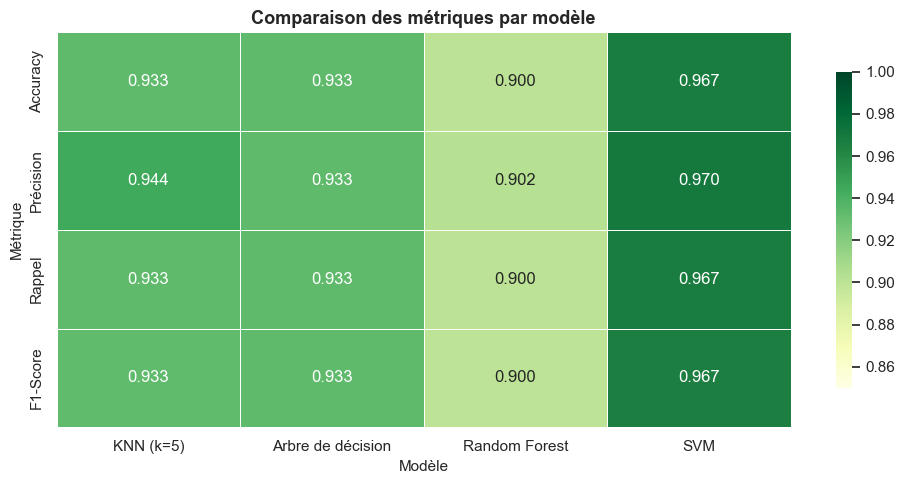

In [16]:
# Visualisation radar-like : heatmap des métriques
plt.figure(figsize=(10, 5))
sns.heatmap(df_resultats.T, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, vmin=0.85, vmax=1.0,
            cbar_kws={'shrink': 0.8})
plt.title('Comparaison des métriques par modèle', fontsize=13, fontweight='bold')
plt.xlabel('Modèle', fontsize=11)
plt.ylabel('Métrique', fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
# Comparaison de régression
print('=== Comparaison des modèles de régression ===\n')

modeles_reg = {
    'Régression linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Arbre de décision': DecisionTreeRegressor(max_depth=5, random_state=42),
}

resultats_reg = []
for nom, modele in modeles_reg.items():
    modele.fit(X_train_r, y_train_r)
    y_p = modele.predict(X_test_r)
    resultats_reg.append({
        'Modèle': nom,
        'MAE': mean_absolute_error(y_test_r, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_test_r, y_p)),
        'R²': r2_score(y_test_r, y_p)
    })

df_reg = pd.DataFrame(resultats_reg).set_index('Modèle')
print(df_reg.round(3).to_string())
print(f'\nMeilleur modèle (R²) : {df_reg["R²"].idxmax()}')
print(f'Meilleur modèle (MAE) : {df_reg["MAE"].idxmin()} (valeur la plus basse)')

=== Comparaison des modèles de régression ===

                        MAE    RMSE     R²
Modèle                                    
Régression linéaire  42.794  53.853  0.453
Ridge                46.139  55.474  0.419
Arbre de décision    45.937  59.380  0.334

Meilleur modèle (R²) : Régression linéaire
Meilleur modèle (MAE) : Régression linéaire (valeur la plus basse)


## 7. Choisir la Bonne Métrique <a id='7'></a>

Le choix de la métrique dépend du **contexte métier**, pas seulement des performances mathématiques.

In [18]:
# Illustration : le paradoxe de l'accuracy sur données déséquilibrées
print('=== Illustration : Données déséquilibrées ===')
print()

# Simuler un dataset : 95% classe 0, 5% classe 1
np.random.seed(42)
n = 1000
y_imbalanced = np.array([0]*950 + [1]*50)
y_pred_bete = np.zeros(n)  # modèle "bête" qui prédit toujours 0

acc_bete = accuracy_score(y_imbalanced, y_pred_bete)
f1_bete = f1_score(y_imbalanced, y_pred_bete, zero_division=0)
recall_bete = recall_score(y_imbalanced, y_pred_bete, zero_division=0)

print(f'Modèle qui prédit TOUJOURS la classe majoritaire (0) :')
print(f'  Accuracy  : {acc_bete:.2f} ({acc_bete*100:.0f}%) ← Paraît bon !')
print(f'  F1-Score  : {f1_bete:.2f} ← Révèle le vrai problème !')
print(f'  Rappel    : {recall_bete:.2f} ← Détecte 0 cas rares !')
print()
print('⚠️  Un modèle avec 95% d\'accuracy peut être totalement inutile')
print('    si les données sont déséquilibrées !')

=== Illustration : Données déséquilibrées ===

Modèle qui prédit TOUJOURS la classe majoritaire (0) :
  Accuracy  : 0.95 (95%) ← Paraît bon !
  F1-Score  : 0.00 ← Révèle le vrai problème !
  Rappel    : 0.00 ← Détecte 0 cas rares !

⚠️  Un modèle avec 95% d'accuracy peut être totalement inutile
    si les données sont déséquilibrées !


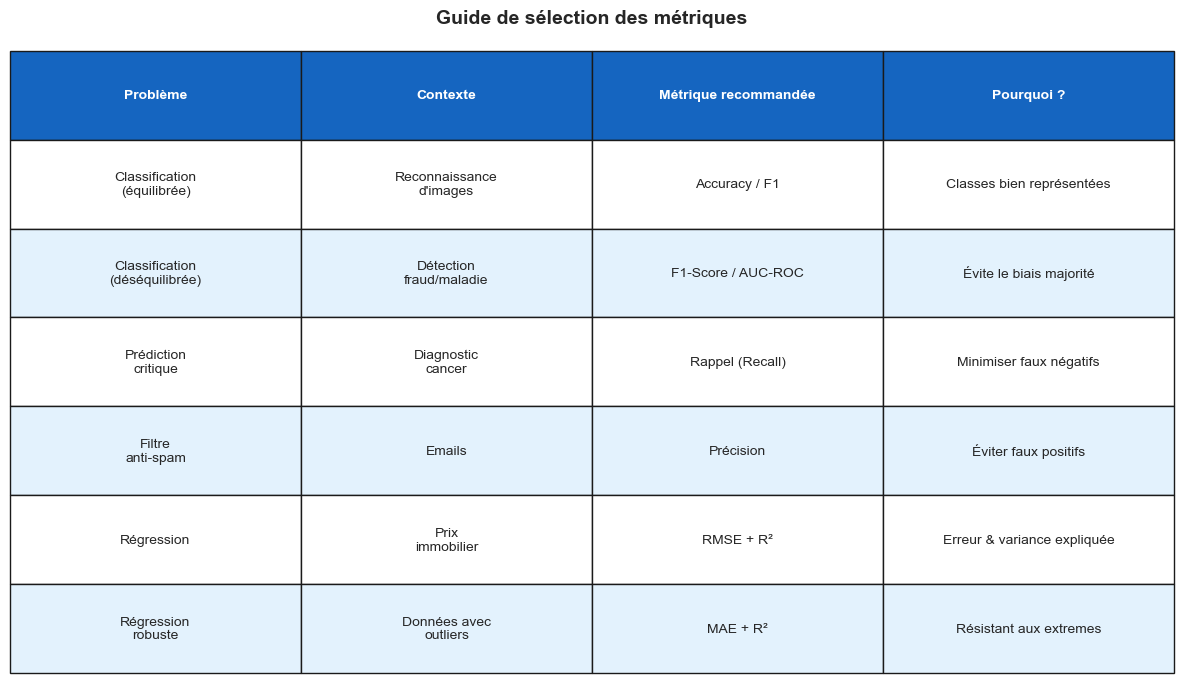

In [19]:
# Guide de sélection des métriques
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

table_data = [
    ['Problème', 'Contexte', 'Métrique recommandée', 'Pourquoi ?'],
    ['Classification\n(équilibrée)', 'Reconnaissance\nd\'images', 'Accuracy / F1', 'Classes bien représentées'],
    ['Classification\n(déséquilibrée)', 'Détection\nfraud/maladie', 'F1-Score / AUC-ROC', 'Évite le biais majorité'],
    ['Prédiction\ncritique', 'Diagnostic\ncancer', 'Rappel (Recall)', 'Minimiser faux négatifs'],
    ['Filtre\nanti-spam', 'Emails', 'Précision', 'Éviter faux positifs'],
    ['Régression', 'Prix\nimmobilier', 'RMSE + R²', 'Erreur & variance expliquée'],
    ['Régression\nrobuste', 'Données avec\noutliers', 'MAE + R²', 'Résistant aux extremes'],
]

tab = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])

tab.auto_set_font_size(False)
tab.set_fontsize(10)

for j in range(len(table_data[0])):
    tab[0, j].set_facecolor('#1565C0')
    tab[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data)):
    for j in range(len(table_data[0])):
        if i % 2 == 0:
            tab[i, j].set_facecolor('#E3F2FD')
        else:
            tab[i, j].set_facecolor('#FFFFFF')

plt.title('Guide de sélection des métriques', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 🏁 Conclusion

### Résumé des métriques

**Classification :**
- `accuracy_score` → proportion de bonnes prédictions (attention aux classes déséquilibrées)
- `precision_score` → qualité des prédictions positives
- `recall_score` → capacité à trouver tous les cas positifs
- `f1_score` → compromis précision/rappel
- `confusion_matrix` → analyse détaillée des erreurs
- `roc_auc_score` → discrimination globale du modèle

**Régression :**
- `mean_absolute_error` → erreur moyenne en unité réelle
- `mean_squared_error` → pénalise les grandes erreurs
- `r2_score` → % de variance expliquée par le modèle

**Validation :**
- `cross_val_score` → estimation robuste par validation croisée

> 🎯 **Règle d'or** : Il n'existe pas de métrique universelle. Choisissez toujours la métrique en fonction de **l'impact réel des erreurs** dans votre domaine.

In [20]:
# Fonction utilitaire : évaluation complète d'un modèle
def evaluer_modele(modele, X_train, X_test, y_train, y_test, type_probleme='classification'):
    """
    Évalue un modèle et affiche toutes les métriques pertinentes.
    type_probleme : 'classification' ou 'regression'
    """
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    
    print(f'=== Évaluation : {type(modele).__name__} ===')
    
    if type_probleme == 'classification':
        print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
        print(f'F1-Score  : {f1_score(y_test, y_pred, average="weighted"):.3f}')
        print(f'Précision : {precision_score(y_test, y_pred, average="weighted"):.3f}')
        print(f'Rappel    : {recall_score(y_test, y_pred, average="weighted"):.3f}')
        print('\nRapport complet :')
        print(classification_report(y_test, y_pred))
    else:
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        print(f'MAE  : {mae:.3f}')
        print(f'RMSE : {rmse:.3f}')
        print(f'R²   : {r2:.3f} ({r2*100:.1f}% de variance expliquée)')

# Exemple d'utilisation
print('Exemple d\'utilisation de la fonction evaluer_modele :')
print()
evaluer_modele(RandomForestClassifier(n_estimators=50, random_state=42),
               X_train_sc, X_test_sc, y_train, y_test,
               type_probleme='classification')

Exemple d'utilisation de la fonction evaluer_modele :

=== Évaluation : RandomForestClassifier ===
Accuracy  : 0.900
F1-Score  : 0.900
Précision : 0.902
Rappel    : 0.900

Rapport complet :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

